# Proof of Concept EEG Data Analysis

## Data Loading (.json)

In [20]:
import numpy as np
import json
import pandas as pd

In [21]:
data_file = 'POC_Experiment_Data.json'

with open(data_file, 'r') as json_file:
    json_data = json.load(json_file)

In [22]:
def stream_to_dataframe(stream_data):

    values = stream_data['Value']
    info = stream_data.get('Info', [])

    data_dict = {
        "TIMESTAMP": stream_data['TimeStamp'],
        "SAMPLING_RATE": stream_data['SamplingRate']
    }

    for i, name in enumerate(info):
        try: 
            data_dict[f"{name.upper()}"] = [value[i] for value in values]
            
        except IndexError:
            data_dict[f"{name.upper()}"] = values  # fallback for 1D data

    df = pd.DataFrame(data_dict)
    return df

In [23]:
gaze2D_df = stream_to_dataframe(json_data['Gaze2D'])
gaze3D_df = stream_to_dataframe(json_data['Gaze3D'])
pupil_df = stream_to_dataframe(json_data['PupilDiameter'])
gazeOrigin_df = stream_to_dataframe(json_data['GazeOrigin'])
gazeDirection_df = stream_to_dataframe(json_data['GazeDirection'])
marker_df = stream_to_dataframe(json_data['Marker'])
eeg_df = stream_to_dataframe(json_data['EEG'])

In [24]:
# Inspection example

gazeDirection_df.head()

,TIMESTAMP,SAMPLING_RATE,LEFT_X,LEFT_Y,LEFT_Z,RIGHT_X,RIGHT_Y,RIGHT_Z
0,42066.876411,100,0.3016,0.2660,0.9156,0.1584,0.2079,0.9652
1,42066.886429,100,0.2897,0.2543,0.9227,0.1653,0.1624,0.9728
2,42066.896447,100,0.2522,0.2366,0.9383,0.1635,0.1418,0.9763
3,42066.906466,100,0.2428,0.2335,0.9416,0.1699,0.1143,0.9788
4,42066.916484,100,0.2305,0.2121,0.9497,0.1710,0.0905,0.9811


## 

## Event Preparation

Prepare events for use in EEG analysis by adding them to a list with their associated timeframe.

Also associate a label for trial eye movement type: "turn" (turned head), "eyes" (moved eyes only), "open" (opened closed eyes). 

#### Event Types
**'Marker' Stream (originally `Explore_84A1_Marker`)
- Custom MentaLab Events (e.g. "`sw_##`")
- Manual MentaLab Button Events (e.g. "`pb_#`")
**Other**
- Automatic Gaze-AOI Events (loading from external file)  

In [ ]:
## Load Gaze-AOI Events

In [ ]:
## Restrict Gaze-AOI events to only the intended trials

#### Event Labelling
**Gaze-AOI** events are the focus of the EEG epoch, so their label will describe the trial.
Label format: {target (Y/H/U)}{movement (T/E/O)}
- Examples: `YT` (Yoonhee/Turned Head), `UE` (Unfamiliar/Eyes Moved), `HO` (Hailey/Opened Eyes)

**Manual Button Events** and **Custom MentaLab Events** will be kept as references in the EEG script, but re-labeled for clarity. They don't need trial type distinction since this is covered by Gaze-AOI events.
- Manual Button Events - "`button`"
- Custom MentaLab Events - "`start`"

In [ ]:
## Re-label Gaze-AOI Events


## EEG Preprocessing

Preprocess EEG to get the data to a usable state.
1. Filter Continuous EEG Data
2. *(Optional)* Re-reference with Fp2 to remove eye artifacts 
3. Epoch EEG data to Gaze-AOI Events
4. Subtract baseline mean from each epoch (baseline should be before movement)
5. Independent Component Analysis (ICA) to remove noise

#### Imports and Config

In [5]:
import mne
import numpy as np
import pandas as pd

##### GPU Acceleration

For GPU acceleration, run in terminal:

```powershell
pip install cupy
MNE_USE_CUDA=true python -c "import mne; mne.cuda.init_cuda(verbose=True)"
```

In [7]:
# MNE/Jupyter plot setup
%matplotlib inline
# mne.viz.set_3d_backend("notebook")

In [13]:
# Enable CUDA in MNE
mne.utils.set_config('MNE_USE_CUDA', 'true')
# Verify CUDA is enabled
mne.cuda.init_cuda(verbose=True)

#### EEG Data Preparation

In [25]:
print(eeg_df.head())

      TIMESTAMP  SAMPLING_RATE           CH1           CH2          CH3  \
0  42066.955334            250  27452.330078  11584.240234  2029.709961   
1  42066.959326            250  27452.279297  11575.990234  2024.170044   
2  42066.963318            250  27455.089844  11572.889648  2022.510010   
3  42066.967310            250  27453.000000  11573.940430  2023.410034   
4  42066.971302            250  27452.519531  11572.929688  2022.599976   

            CH4           CH5           CH6           CH7           CH8  
0 -12576.769531 -35318.859375  20525.550781 -10323.860352  36517.769531  
1 -12583.589844 -35321.289062  20521.400391 -10320.469727  36516.808594  
2 -12585.259766 -35318.808594  20522.449219 -10320.240234  36517.480469  
3 -12585.740234 -35315.039062  20520.830078 -10309.549805  36516.050781  
4 -12586.400391 -35314.710938  20520.070312 -10287.190430  36514.000000  


In [ ]:
## Build MNE Raw Data with Channel Names
# Channel order:
# 1. FP2, 
# 2. Pz, 
# 3. Cz, 
# 4. PO8, 
# 5. PO7, 
# 6. T8, 
# 7. T7, 
# 8. F2

# Channel label order for MNE
ch_names_desired = ["FP2", "Pz", "Cz", "PO8", "PO7", "T8", "T7", "F2"]

# Current EEG columns
meta_cols = {"TIMESTAMP", "SAMPLING_RATE"}
eeg_cols_current = [c for c in eeg_df.columns if c not in meta_cols]

if len(eeg_cols_current) != len(ch_names_desired):
    print(
        f"Warning: expected {len(ch_names_desired)} EEG channels, found {len(eeg_cols_current)}: {eeg_cols_current}"
    )

# Prepare numeric data matrix (n_channels x n_times) for MNE RawArray
# Coerce to numeric and replace NaNs with 0 for stability (does not modify the original DataFrame)
eeg_numeric = eeg_df[eeg_cols_current].apply(pd.to_numeric, errors='coerce')
data = eeg_numeric.to_numpy().T.astype(float, copy=False)
np.nan_to_num(data, copy=False)

# Sampling frequency
sfreq = float(eeg_df["SAMPLING_RATE"].iloc[0]) if "SAMPLING_RATE" in eeg_df.columns else None

# Create MNE Info and RawArray using our desired channel labels (truncate in case of mismatch)
ch_names = ch_names_desired[: data.shape[0]]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info, verbose=False)

# Apply a standard montage that includes these names; standard_1005 is comprehensive and includes F2
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

print(raw)
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'])

<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0


#### 1. Filter Continuous EEG Data

Apply a Butterworth Bandpass Filter (BPF)
- Low-pass of 40 Hz, high-pass of 1 Hz

Apply a Bandstop Filter (BPF) at power line noise frequency (60 Hz)

In [ ]:
## Band-pass Filter EEG Data (1-40 Hz)
raw_filt = raw.copy().load_data()  # Use a copy

l_freq = 1.0  # Hz
h_freq = 40.0  # Hz

# Zero-phase FIR
a = raw_filt.filter(l_freq, h_freq)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00

<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Filtered channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0


Effective window size : 8.192 (s)


Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


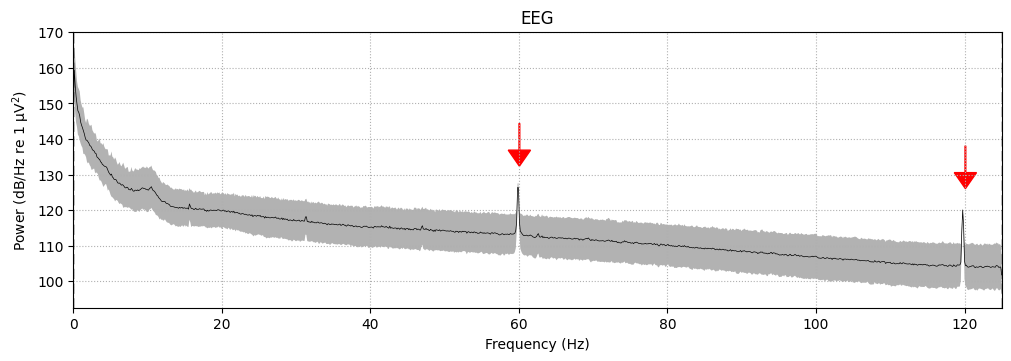

In [36]:
## View Spectrum to Identify Power Line Noise

def add_arrows(axes):
    """Add arrows at 60 Hz and its harmonics without indexing past data range."""
    harmonics = (60, 120, 180, 240)
    for ax in axes:
        # Choose the plotted line with the most points to derive freqs/psd safely
        lines = [ln for ln in ax.lines if hasattr(ln, "get_xdata")]
        if not lines:
            continue
        line = max(lines, key=lambda ln: len(ln.get_xdata()))
        freqs = np.asarray(line.get_xdata())
        psds = np.asarray(line.get_ydata())
        if freqs.size == 0 or psds.size == 0:
            continue

        fmax_plot = float(freqs[-1])
        for freq in harmonics:
            # Skip harmonics outside the plotted frequency range
            if freq > fmax_plot:
                continue
            # Find insertion index and clamp to valid range
            idx = int(np.searchsorted(freqs, freq, side="left"))
            if idx >= freqs.size:
                idx = freqs.size - 1
            if idx < 0:
                idx = 0

            # Robust neighborhood for peak arrow height
            i0 = max(0, idx - 4)
            i1 = min(psds.size, idx + 5)
            if i0 >= i1:
                y = float(psds[idx])
            else:
                y = float(psds[i0:i1].max())

            # Draw a short downward arrow
            ax.arrow(
                x=float(freqs[idx]),
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )

# Plot PSD and annotate
fig = raw.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)
add_arrows(fig.axes[:2])

In [37]:
## Notch filter at 60 Hz
freqs = [60.0, 120.0]
raw_filt.notch_filter(freqs=[60.0, 120.0])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)



<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>

<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Filtered channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


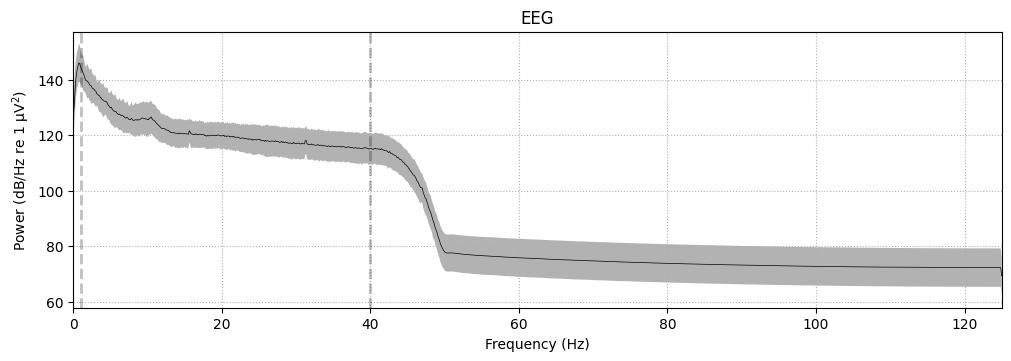

In [38]:
## Display Filtered Data Info and Plot PSD
print(raw_filt)
print("Filtered channels:", raw_filt.ch_names)
print("Sampling rate:", raw_filt.info['sfreq'])
fig = raw_filt.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

#### 2. *(Optional)* Re-reference with Fp2 to remove eye artifacts

#### 3. Epoch EEG to Gaze-AOI Events

#### 4. Subtract baseline mean from each Epoch  

#### 5. Independent Component Analysis (ICA) to remove artifacts

## ERP Results/Analysis

Visualize and calculate the ERP results across trials.

This should allow for visualization of specific eye movement types and targets, averaging or selecting specific trials as necessary.

We also want to analyze N250 (PO8,PO7,T8,T7,F2) and P300 (Pz,Cz) in particular. The plots will show a shaded region that is considered when averaging to find these components, and the scripts should print out the associated voltage level (Mean +/- SD)